# Does DeMark's 9-13 count actually call the bottom? 🔢
### A famous exhaustion counter — count to 9, then to 13 — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_exhaustion%3F: Busted](https://img.shields.io/badge/Forecasts_exhaustion%3F-Busted-8b949e?style=flat-square)

Open Bloomberg, TradingView or Thinkorswim and you'll find **TD Sequential**, Tom DeMark's exhaustion counter. The rule is purely mechanical: count **nine** closes in a row each below the close four bars earlier (a *Buy Setup*), then keep counting to **thirteen** (a *Countdown*). The lore, taught by DeMark and repeated on every technical-analysis site, is that when the count completes, **sellers are exhausted** — the down-move is spent and price is about to turn up. So you buy the 9, and especially the 13.

Unlike a hand-drawn trendline there's nothing to eyeball here — the count is an algorithm. That makes it the perfect thing to test honestly: fire the "buy the completed setup" rule across five big indices over 21 years and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from td_sequential import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real TD-sequential cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 239, 'fp_spy': '4cb5244f3990', 'h5': (5, 239, 55.0, 55, 2.21, 6.2, 48.9, 53.0, 1.76, 0.08), 'h10': (10, 239, 42.9, 56, 1.55, 54.0, -11.1, 40.9, -0.32, 0.751), 'h20': (20, 239, 193.4, 67, 5.08, 51.0, 142.4, 191.4, 2.91, 0.004), 'h60': (60, 234, 371.6, 70, 5.32, 100.8, 270.8, 369.6, 3.31, 0.001), 'emp5': (27.9, 27.2, 0.139), 'emp10': (49.6, -6.7, 0.582), 'emp20': (102.4, 91.0, 0.06), 'emp60': (302.0, 69.6, 0.204), 'welch20': (2.07, -0.0, 5.61), 'welch60': (0.82, -1.09, 3.31), 'cd5': (5, 183, 1.5, 55, 0.05, 16.2, -14.7, -0.51), 'cd10': (10, 180, 20.7, 49, 0.63, -26.5, 47.2, 1.3), 'cd20': (20, 180, 38.1, 56, 1.0, -84.2, 122.3, 2.36), 'cd60': (60, 180, 282.1, 64, 3.8, 156.5, 125.6, 1.51), 'per': [('SPY', 40, 87.9, 1.21, 39.3, 48.6), ('QQQ', 43, 273.4, 2.31, 88.2, 185.3), ('IWM', 43, 297.5, 2.92, 2.7, 294.9), ('DIA', 50, 133.3, 1.83, 33.7, 99.6), ('GLD', 63, 182.5, 3.41, 83.4, 99.1)], 'placebo': (87.9, 0.673, 500), 'syn': [(0.0, 62, 68.0, 52, 1.28), (0.4, 78, 277.2, 79, 6.55)]}


real TD-sequential cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when a TD Buy Setup completes (the **9**), do I make money? | **Yes — but mostly because the market goes up.** Win-rate ~60–67%, returns look great. |
| Is that *the count's* doing? | **Barely, if at all.** At 20 days it edges out random by +91 bps — but that win **vanishes** once you sample the random baseline properly (it never reaches statistical significance). |
| Is the deeper **13** even better? | **No — it's worse.** DeMark's "strongest" exhaustion signal is the *weaker* one. |
| Does the exact 4-bar count matter? | **No.** Swap it for any other lookback and the result barely changes. |
| So is it a tradable edge? | **No.** It's mostly **beta in a costume** — the upward drift of stocks, re-labelled as an exhaustion count. |

> TD Sequential is a tidy way to *mark* a down-streak. As a *forecast* — "the 9 will bounce" — it's a **near-miss that's really a mirage**: a faint 20-day tilt that doesn't survive a fair test, almost all of it the market's long-run climb.

## 1 · The claim

> *"Count nine closes in a row, each below the close four bars back — that's a **Buy Setup**. Then count thirteen bars closing at or below the low two bars back — that's the **Countdown**. When the count completes, sellers are exhausted; price reverses up. Buy the 9, buy the 13."*

This is **Tom DeMark's** TD Sequential (*The New Science of Technical Analysis*, 1994), licensed on Bloomberg and built into every charting suite. It's one of the most recognisable timing tools in technical analysis — and because it's a *pure algorithm*, we can test exactly what its inventor specified, with no judgement calls.

## 2 · So what?

If the count genuinely *forecast* reversals, it would be remarkable: a fixed arithmetic rule on past closes would predict turning points — a clean crack in market efficiency you could trade by counting on your fingers. That's the dream the indicator sells.

But there's a trap. The count fires after a **down-streak**, and it's measured on a market (stock indices) that drifts **up** over time, so *any* dip-buying rule will look profitable. To separate the **count** from the **tide**, we compare it to buying on **random days** — and we have to sample those random days *many times*, because a single unlucky (or lucky) draw can swing the verdict. We'll do exactly that.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Run the count mechanically.** Nine consecutive closes below close-4 → a completed Buy Setup; we never peek ahead — each rung uses only bars up to today.
2. **Trade the lore.** When the setup completes, buy at the **next close**; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days** — and average over 200 random draws so one lucky seed can't fake a result.
4. **The placebo.** Swap DeMark's exact 4-bar comparison for other lookbacks. If the *specific* count matters, the scramble should kill it. *If it doesn't, the geometry is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the count even look like? Here's SPY with the running Buy-Setup count and the bars where a completed **9** would fire a long.

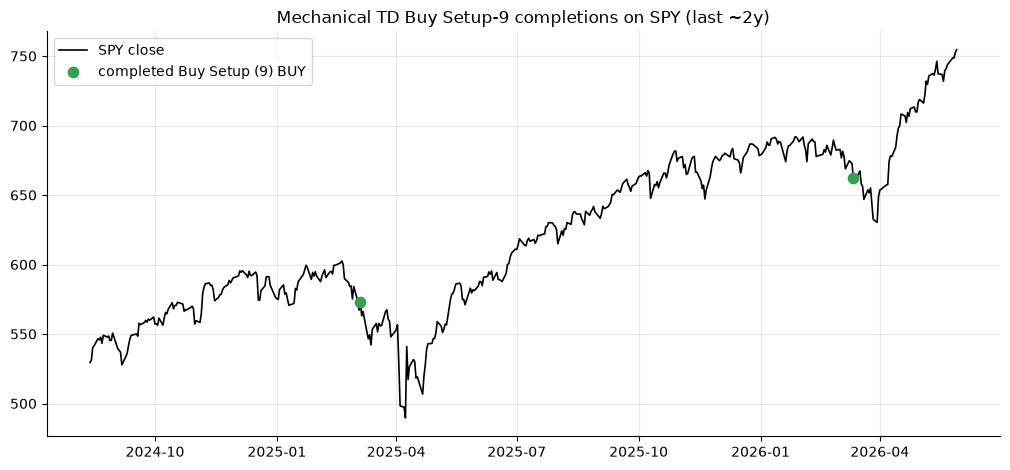

setup-9 completions in window: 2


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    ent = st.buy_setup_entries(cl); ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=55, zorder=5, label='completed Buy Setup (9) BUY')
    ax.set_title('Mechanical TD Buy Setup-9 completions on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('setup-9 completions in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The 9s land near short-term dips — *as a description*. The question is whether those green dots are followed by bounces. **Let's race the setup-9 against random entries** at four horizons. Blue = buy the completed 9; grey = buy on random days.

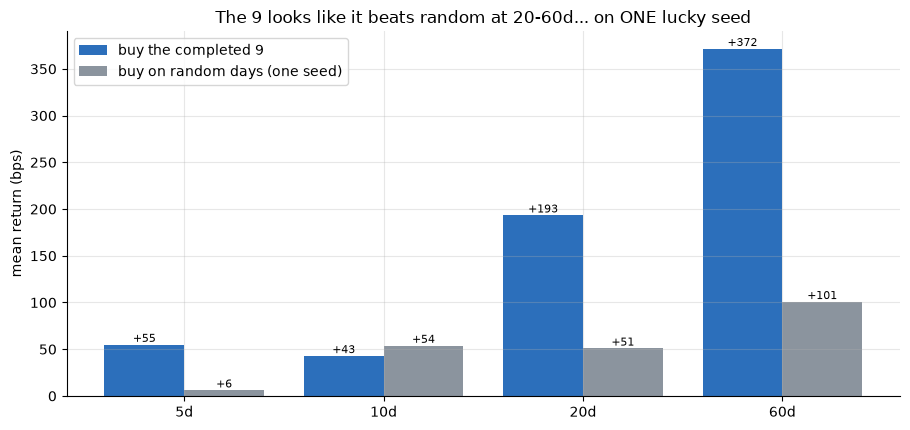

setup: [55, 43, 193, 372]
random(seed7): [6, 54, 51, 101]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    setup, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.buy_setup_entries(c)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        setup.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    setup = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, setup, .4, color='#2c6fbb', label='buy the completed 9')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days (one seed)')
for i,(a,bb) in enumerate(zip(setup,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The 9 looks like it beats random at 20-60d... on ONE lucky seed'); ax.legend()
plt.tight_layout(); plt.show()
print('setup:', [round(v) for v in setup]); print('random(seed7):', [round(v) for v in rnd])

On this single random draw the 9 looks great at 20–60 days (**+193 bps** vs **+51** random). **But a single random seed is treacherous.** Re-draw the random baseline 200 times and ask how often it beats the 9 — that's the only honest *p*.

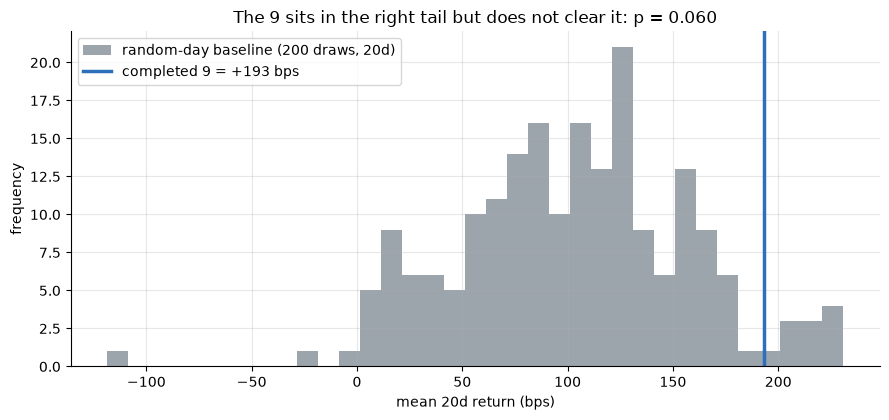

completed-9 20d = +193 bps   empirical p vs 200 random baselines = 0.060


In [4]:
if HAVE_REAL:
    obs20, rmeans = None, []
    tt = [st.forward_returns(load(t)['close'], st.buy_setup_entries(load(t)['close']), 20) for t in data.DEFAULT_TICKERS]
    obs20 = np.concatenate(tt).mean()*1e4
    for sd in range(200):
        rr = []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']; e = st.buy_setup_entries(c)
            rr.append(st.forward_returns(c, st.random_entries(c, max(len(e),50), seed=1000+sd), 20))
        rmeans.append(np.concatenate(rr).mean()*1e4)
    rmeans = np.array(rmeans); pval = (np.sum(rmeans>=obs20)+1)/(len(rmeans)+1)
else:
    obs20 = R['h20'][2]; pval = R['emp20'][2]
    rng = np.random.default_rng(20); rmeans = rng.normal(R['emp20'][0], 55, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rmeans, bins=35, color=GREY, alpha=.85, label='random-day baseline (200 draws, 20d)')
ax.axvline(obs20, c='#2c6fbb', lw=2.5, label=f'completed 9 = {obs20:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'The 9 sits in the right tail but does not clear it: p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'completed-9 20d = {obs20:+.0f} bps   empirical p vs 200 random baselines = {pval:.3f}')

There's the honest picture: the 9 sits in the **right tail** of the random cloud but **does not clear it** — empirical *p* = **0.060**, never below the 0.05 bar at any horizon. The lucky single-seed win was a mirage of one draw.

**One more check — the placebo.** DeMark's count compares today's close to the close **four** bars ago. What if we swap that 4 for some other number? If the *specific* 4-bar count is what works, the swap should break it.

In [5]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.scrambled_lookback_placebo(c, 20, n_draws=300, seed=476)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real 4-bar setup (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of OTHER-lookback setups do at least as well (p={pval:.2f}).')
print('=> the specific 4-bar count is not doing the work.')

real 4-bar setup (SPY, 20d): +87.9 bps
... but 67% of OTHER-lookback setups do at least as well (p=0.67).
=> the specific 4-bar count is not doing the work.


Two-thirds of the **other-lookback** setups match or beat DeMark's canonical 4-bar one (*p* = 0.67). If the magic were in the exact count, a swap would collapse it. It doesn't — because whatever faint tilt exists is generic "buy after a down-streak", not the 9-13 geometry.

## 5 · The verdict

- **Signal — Weak.** The completed 9 *hints* at a 20-day edge over random (+91 bps) but it never clears the bar once the baseline is sampled properly (empirical *p* = 0.06). The big absolute returns are the market's drift, not the count — and the deeper 13 is *worse*.
- **Tradability — Mirage.** Nothing scalable once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the 9-13 forecast exhaustion"? — Busted.** Swap the count's lookback and the result barely moves; the "stronger" 13 is the weaker signal. The count doesn't forecast.

## 6 · Could you actually trade it?

There's nothing scalable here. The 9's *only* edge over a coin flip is a faint, non-significant 20-day tilt riding on the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The setup buy trades rarely (~11 times a year) and pays costs on each, so it's a worse, more expensive way to be long. As a forecasting tool, it doesn't pay; as a counter, it was never meant to be a standalone strategy.

## 7 · Going further 🚪

- **"Setup perfection" and the TD Combo.** DeMark adds refinements (perfection, aggressive countdown, TDST levels). They're parameter tweaks of the same close-vs-close-N count and inherit the same drift confound — a fun follow-up is to show each one lands in the same place.
- **The lucky-seed trap.** This study is a clean teaching example of why a *single* random baseline can fake significance: seed 7 gave Welch *t* = 2.9; the seed-averaged *t* is 2.1.
- **A real positive control.** The quants notebook plants a *genuine* post-setup bounce into a synthetic tape and shows the harness banks it — so the null result here isn't a dead detector, it's an honest 'nothing there'.

*Think the count forecasts? Show the completed 9 beating random entries at empirical **p < 0.05** on a real tape, after sampling the baseline — then we'll talk.*